In [1]:
!pip install xgboost lightgbm

In [2]:
# ---------------------------------------------------------------
# Section 0: Setup and Configuration
# ---------------------------------------------------------------
# Data Handling & Math
import pandas as pd
import numpy as np
import time
import os
import warnings

# Scikit-learn Tools
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# ML Models
import xgboost as xgb
import lightgbm as lgb
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Plotting
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

# --- Set Random Seeds (Full Deterministic for PyTorch) ---
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_STATE)
    torch.cuda.manual_seed_all(RANDOM_STATE)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# ---------------------------------------------------------------
# Section 1: Data Loading and Preprocessing Definition
# ---------------------------------------------------------------
df = pd.read_csv('/content/Churn_Modelling.csv') #**** DATASET PATH FILE ****
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# --- Define Preprocessor ---
categorical_features = ['Geography', 'Gender']
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)])

# --- Prepare Full X and y ---
X = df.drop('Exited', axis=1)
y = df['Exited'].values # Use .values for numpy array

# --- Get Feature Names ---
preprocessor.fit(X) # Fit preprocessor temporarily
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names = numerical_features + list(ohe_feature_names)
INPUT_DIM = len(feature_names)

print(f"Data loaded. Preprocessor defined. Input dimension: {INPUT_DIM}")

Data loaded. Preprocessor defined. Input dimension: 11


In [5]:
# ---------------------------------------------------------------
# Section 2: Model Architectures (PyTorch Models)
# ---------------------------------------------------------------
# --- Model 1: CCP-Net (Adapted) ---
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, i, o, h): super(MultiHeadSelfAttention, self).__init__(); self.h=h; self.o=o; self.q=nn.Linear(i,o); self.k=nn.Linear(i,o); self.v=nn.Linear(i,o); self.f=nn.Linear(o,o); self.ln=nn.LayerNorm(o)
    def forward(self, x): b,s,_=x.size(); q=self.q(x); k=self.k(x); v=self.v(x); q=q.view(b,s,self.h,self.o//self.h).permute(0,2,1,3); k=k.view(b,s,self.h,self.o//self.h).permute(0,2,1,3); v=v.view(b,s,self.h,self.o//self.h).permute(0,2,1,3); s_=torch.matmul(q,k.transpose(-1,-2))/(self.o**0.5); w=F.softmax(s_,dim=-1); o=torch.matmul(w,v); o=o.permute(0,2,1,3).contiguous().view(b,s,self.o); o=self.ln(o+x); return self.f(o)
class BiLSTM(nn.Module):
    def __init__(self, i, h, n=1): super(BiLSTM, self).__init__(); self.lstm=nn.LSTM(i,h,n,bidirectional=True,batch_first=True)
    def forward(self, x): o,_=self.lstm(x); return o
class CCPNetAdapted(nn.Module):
    def __init__(self, i, l, c, o=1, h=1): super(CCPNetAdapted,self).__init__(); self.att=MultiHeadSelfAttention(i,i,h); self.lstm=BiLSTM(i,l); self.d1=nn.Dropout(p=0.3); self.fc1=nn.Linear(l*2,c); self.cnn1=nn.Conv1d(c,c,1); self.d2=nn.Dropout(p=0.3); self.cnn2=nn.Conv1d(c,c,1); self.fc2=nn.Linear(c,o); self.sig=nn.Sigmoid()
    def forward(self, x): x=x.unsqueeze(1); a=self.att(x); l,_=self.lstm.lstm(a); l=self.d1(l); f_in=l[:,-1,:]; fc_c=self.fc1(f_in); c_in=fc_c.unsqueeze(2); c1=F.relu(self.cnn1(c_in)); c1=self.d2(c1); c2=F.relu(self.cnn2(c1)); p=c2.squeeze(2); out=self.fc2(p); return self.sig(out)

# --- Model 2: CustomMLP ---
class CustomMLP(nn.Module):
    def __init__(self, i): super(CustomMLP,self).__init__(); self.l1=nn.Linear(i,64); self.l2=nn.Linear(64,32); self.l3=nn.Linear(32,16); self.lo=nn.Linear(16,1); self.relu=nn.ReLU(); self.drop=nn.Dropout(p=0.2); self.sig=nn.Sigmoid()
    def forward(self, x): x=self.relu(self.l1(x)); x=self.drop(x); x=self.relu(self.l2(x)); x=self.drop(x); x=self.relu(self.l3(x)); x=self.lo(x); return self.sig(x)

print("PyTorch Model Architectures defined.")

PyTorch Model Architectures defined.


In [6]:
# ---------------------------------------------------------------
# Section 3: K-Fold Cross-Validation Setup and Loop
# ---------------------------------------------------------------
N_SPLITS = 5
NUM_EPOCHS = 30 # Epochs for NN models
LEARNING_RATE = 0.001
BATCH_SIZE = 32

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_results = {
    "CCP-Net": [], "MLP": [], "XGBoost": [],
    "LightGBM": [], "RandomForest": [], "LogisticReg": []
}

# --- Lists to store fold accuracies for ALL models ---
results = {
    "CCP-Net": [], "MLP": [], "XGBoost": [],
    "LightGBM": [], "RandomForest": [], "LogisticReg": []
}

fold_count = 0
start_time_total = time.time()

print(f"\nStarting {N_SPLITS}-Fold Cross-Validation for 6 models...")

# --- K-Fold Loop ---
for train_index, val_index in skf.split(X, y):
    fold_count += 1
    print(f"\n--- Fold {fold_count}/{N_SPLITS} ---")
    start_time_fold = time.time()

    # 1. Split data for this fold
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y[train_index], y[val_index]

    # 2. Preprocess data (Fit on Train, Transform both)
    X_train_fold_processed = preprocessor.fit_transform(X_train_fold)
    X_val_fold_processed = preprocessor.transform(X_val_fold)
    X_train_fold_scaled = X_train_fold_processed.toarray() if hasattr(X_train_fold_processed, "toarray") else X_train_fold_processed
    X_val_fold_scaled = X_val_fold_processed.toarray() if hasattr(X_val_fold_processed, "toarray") else X_val_fold_processed

    # --- PyTorch Training ---
    X_train_fold_tensor = torch.tensor(X_train_fold_scaled.astype(np.float32))
    y_train_fold_tensor = torch.tensor(y_train_fold.astype(np.float32)).view(-1, 1)
    X_val_fold_tensor = torch.tensor(X_val_fold_scaled.astype(np.float32))
    y_val_fold_tensor = torch.tensor(y_val_fold.astype(np.float32)).view(-1, 1)
    train_fold_loader = DataLoader(TensorDataset(X_train_fold_tensor, y_train_fold_tensor), batch_size=BATCH_SIZE, shuffle=True)
    val_fold_loader = DataLoader(TensorDataset(X_val_fold_tensor, y_val_fold_tensor), batch_size=BATCH_SIZE, shuffle=False)

    # Train/Eval CCP-Net
    LSTM_HIDDEN_DIM, CNN_HIDDEN_DIM, NUM_HEADS = 32, 16, 1
    model_ccpnet_fold = CCPNetAdapted(INPUT_DIM, LSTM_HIDDEN_DIM, CNN_HIDDEN_DIM).to(device)
    loss_fn_ccp = nn.BCELoss(); optimizer_ccp = torch.optim.Adam(model_ccpnet_fold.parameters(), lr=LEARNING_RATE)
    for epoch in range(NUM_EPOCHS):
        model_ccpnet_fold.train()
        for X_batch, y_batch in train_fold_loader: X_batch, y_batch = X_batch.to(device), y_batch.to(device); y_pred = model_ccpnet_fold(X_batch); loss = loss_fn_ccp(y_pred, y_batch); optimizer_ccp.zero_grad(); loss.backward(); optimizer_ccp.step()

    all_train_preds_ccp = []
    all_train_labels_ccp = []
    with torch.no_grad():
        for X_batch, y_batch in train_fold_loader:
            y_pred = model_ccpnet_fold(X_batch.to(device))
            all_train_preds_ccp.extend((y_pred > 0.5).float().cpu().numpy())
            all_train_labels_ccp.extend(y_batch.cpu().numpy())


    acc_train_ccp = accuracy_score(np.array(all_train_labels_ccp).flatten(),
                                  np.array(all_train_preds_ccp).flatten())
    train_results["CCP-Net"].append(acc_train_ccp)

    all_preds_ccp = []
    with torch.no_grad():
        for X_batch, _ in val_fold_loader: X_batch = X_batch.to(device); y_pred = model_ccpnet_fold(X_batch); predicted_labels = (y_pred > 0.5).float(); all_preds_ccp.extend(predicted_labels.cpu().numpy())
    acc_ccp = accuracy_score(y_val_fold, np.array(all_preds_ccp).flatten()); results["CCP-Net"].append(acc_ccp)
    print(f"CCP-Net Fold {fold_count} Acc: {acc_ccp * 100:.2f}%")

    # Train/Eval MLP
    model_mlp_fold = CustomMLP(INPUT_DIM).to(device)
    loss_fn_mlp = nn.BCELoss(); optimizer_mlp = torch.optim.Adam(model_mlp_fold.parameters(), lr=LEARNING_RATE)
    for epoch in range(NUM_EPOCHS):
        model_mlp_fold.train()
        for X_batch, y_batch in train_fold_loader: X_batch, y_batch = X_batch.to(device), y_batch.to(device); y_pred = model_mlp_fold(X_batch); loss = loss_fn_mlp(y_pred, y_batch); optimizer_mlp.zero_grad(); loss.backward(); optimizer_mlp.step()

    model_mlp_fold.eval()
    all_train_preds_mlp = []
    all_train_labels_mlp = []
    with torch.no_grad():
        for X_batch, y_batch in train_fold_loader:
            y_pred = model_mlp_fold(X_batch.to(device))
            all_train_preds_mlp.extend((y_pred > 0.5).float().cpu().numpy())
            all_train_labels_mlp.extend(y_batch.cpu().numpy()) # เก็บเฉลยไว้ตรงนี้
    acc_train_mlp = accuracy_score(np.array(all_train_labels_mlp).flatten(),
                                  np.array(all_train_preds_mlp).flatten())
    train_results["MLP"].append(acc_train_mlp)

    all_preds_mlp = []
    with torch.no_grad():
        for X_batch, _ in val_fold_loader: X_batch = X_batch.to(device); y_pred = model_mlp_fold(X_batch); predicted_labels = (y_pred > 0.5).float(); all_preds_mlp.extend(predicted_labels.cpu().numpy())
    acc_mlp = accuracy_score(y_val_fold, np.array(all_preds_mlp).flatten()); results["MLP"].append(acc_mlp)
    print(f"MLP Fold {fold_count} Acc: {acc_mlp * 100:.2f}%")

    # --- Scikit-learn / XGBoost / LightGBM Training ---
    print(f"Training Scikit-learn models (Fold {fold_count})...")

    # XGBoost
    model_xgb_fold = xgb.XGBClassifier(objective='binary:logistic', use_label_encoder=False, eval_metric='logloss', n_estimators=100, max_depth=5, learning_rate=0.1, random_state=RANDOM_STATE)
    model_xgb_fold.fit(X_train_fold_scaled, y_train_fold)

    y_pred_train_xgb = model_xgb_fold.predict(X_train_fold_scaled)
    acc_train_xgb = accuracy_score(y_train_fold, y_pred_train_xgb)
    train_results["XGBoost"].append(acc_train_xgb)

    y_pred_xgb = model_xgb_fold.predict(X_val_fold_scaled)
    acc_xgb = accuracy_score(y_val_fold, y_pred_xgb); results["XGBoost"].append(acc_xgb)
    print(f"XGBoost Fold {fold_count} Acc: {acc_xgb * 100:.2f}%")

    # LightGBM
    model_lgbm_fold = lgb.LGBMClassifier(random_state=RANDOM_STATE)
    model_lgbm_fold.fit(X_train_fold_scaled, y_train_fold)

    train_results["LightGBM"].append(accuracy_score(y_train_fold, model_lgbm_fold.predict(X_train_fold_scaled)))

    y_pred_lgbm = model_lgbm_fold.predict(X_val_fold_scaled)
    acc_lgbm = accuracy_score(y_val_fold, y_pred_lgbm); results["LightGBM"].append(acc_lgbm)
    print(f"LightGBM Fold {fold_count} Acc: {acc_lgbm * 100:.2f}%")

    # Random Forest
    model_rf_fold = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    model_rf_fold.fit(X_train_fold_scaled, y_train_fold)

    train_results["RandomForest"].append(accuracy_score(y_train_fold, model_rf_fold.predict(X_train_fold_scaled)))

    y_pred_rf = model_rf_fold.predict(X_val_fold_scaled)
    acc_rf = accuracy_score(y_val_fold, y_pred_rf); results["RandomForest"].append(acc_rf)
    print(f"RandomForest Fold {fold_count} Acc: {acc_rf * 100:.2f}%")

    # Logistic Regression
    model_lr_fold = LogisticRegression(random_state=RANDOM_STATE)
    model_lr_fold.fit(X_train_fold_scaled, y_train_fold)

    train_results["LogisticReg"].append(accuracy_score(y_train_fold, model_lr_fold.predict(X_train_fold_scaled)))

    y_pred_lr = model_lr_fold.predict(X_val_fold_scaled)
    acc_lr = accuracy_score(y_val_fold, y_pred_lr); results["LogisticReg"].append(acc_lr)
    print(f"LogisticReg Fold {fold_count} Acc: {acc_lr * 100:.2f}%")

    end_time_fold = time.time()
    print(f"Fold {fold_count} finished in {end_time_fold - start_time_fold:.2f} seconds.")


Starting 5-Fold Cross-Validation for 6 models...

--- Fold 1/5 ---
CCP-Net Fold 1 Acc: 85.65%
MLP Fold 1 Acc: 85.65%
Training Scikit-learn models (Fold 1)...
XGBoost Fold 1 Acc: 86.15%
[LightGBM] [Info] Number of positive: 1629, number of negative: 6371
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001703 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203625 -> initscore=-1.363790
[LightGBM] [Info] Start training from score -1.363790
LightGBM Fold 1 Acc: 86.00%
RandomForest Fold 1 Acc: 85.45%
LogisticReg Fold 1 Acc: 80.95%
Fold 1 finished in 71.73 seconds.

--- Fold 2/5 ---
CCP-Net Fold 2 Acc: 84.85%
MLP Fold 2 Acc: 85.60%
Training Scikit-learn models (Fold 2)...
XGBoost Fold 2 Acc: 86.05%
[LightGBM] [Info] Number of positive: 1629, number of negative:


### Cross-Validation Results Summary ###
Model              | Average Accuracy | Std Dev
-------------------|------------------|----------
CCP-Net            |      85.74      % | 0.58%
MLP                |      85.91      % | 0.30%
XGBoost            |      86.33      % | 0.25%
LightGBM           |      86.11      % | 0.17%
RandomForest       |      86.02      % | 0.46%
LogisticReg        |      81.04      % | 0.53%

Total Cross-Validation time: 334.44 seconds.

Conclusion: Based on average K-Fold accuracy, **XGBoost** performs the best for this dataset.


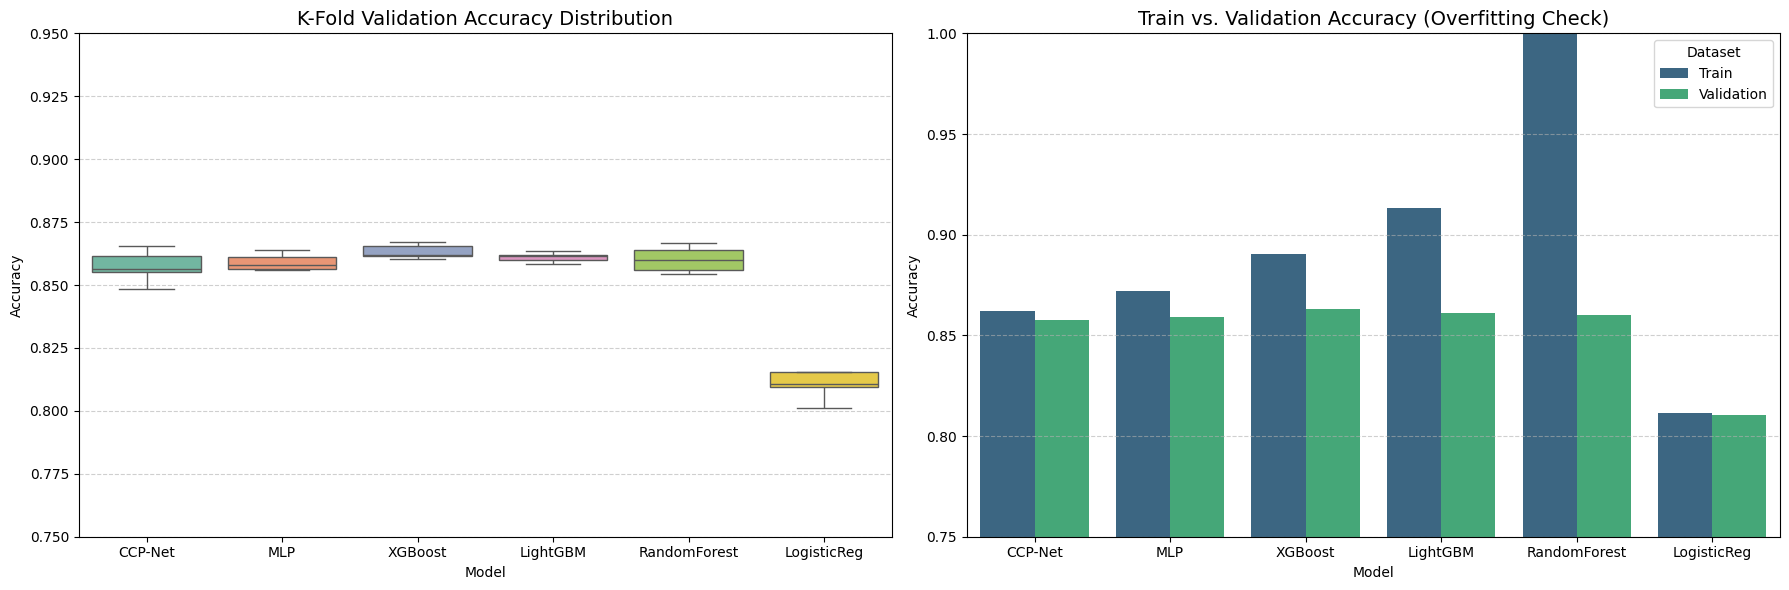

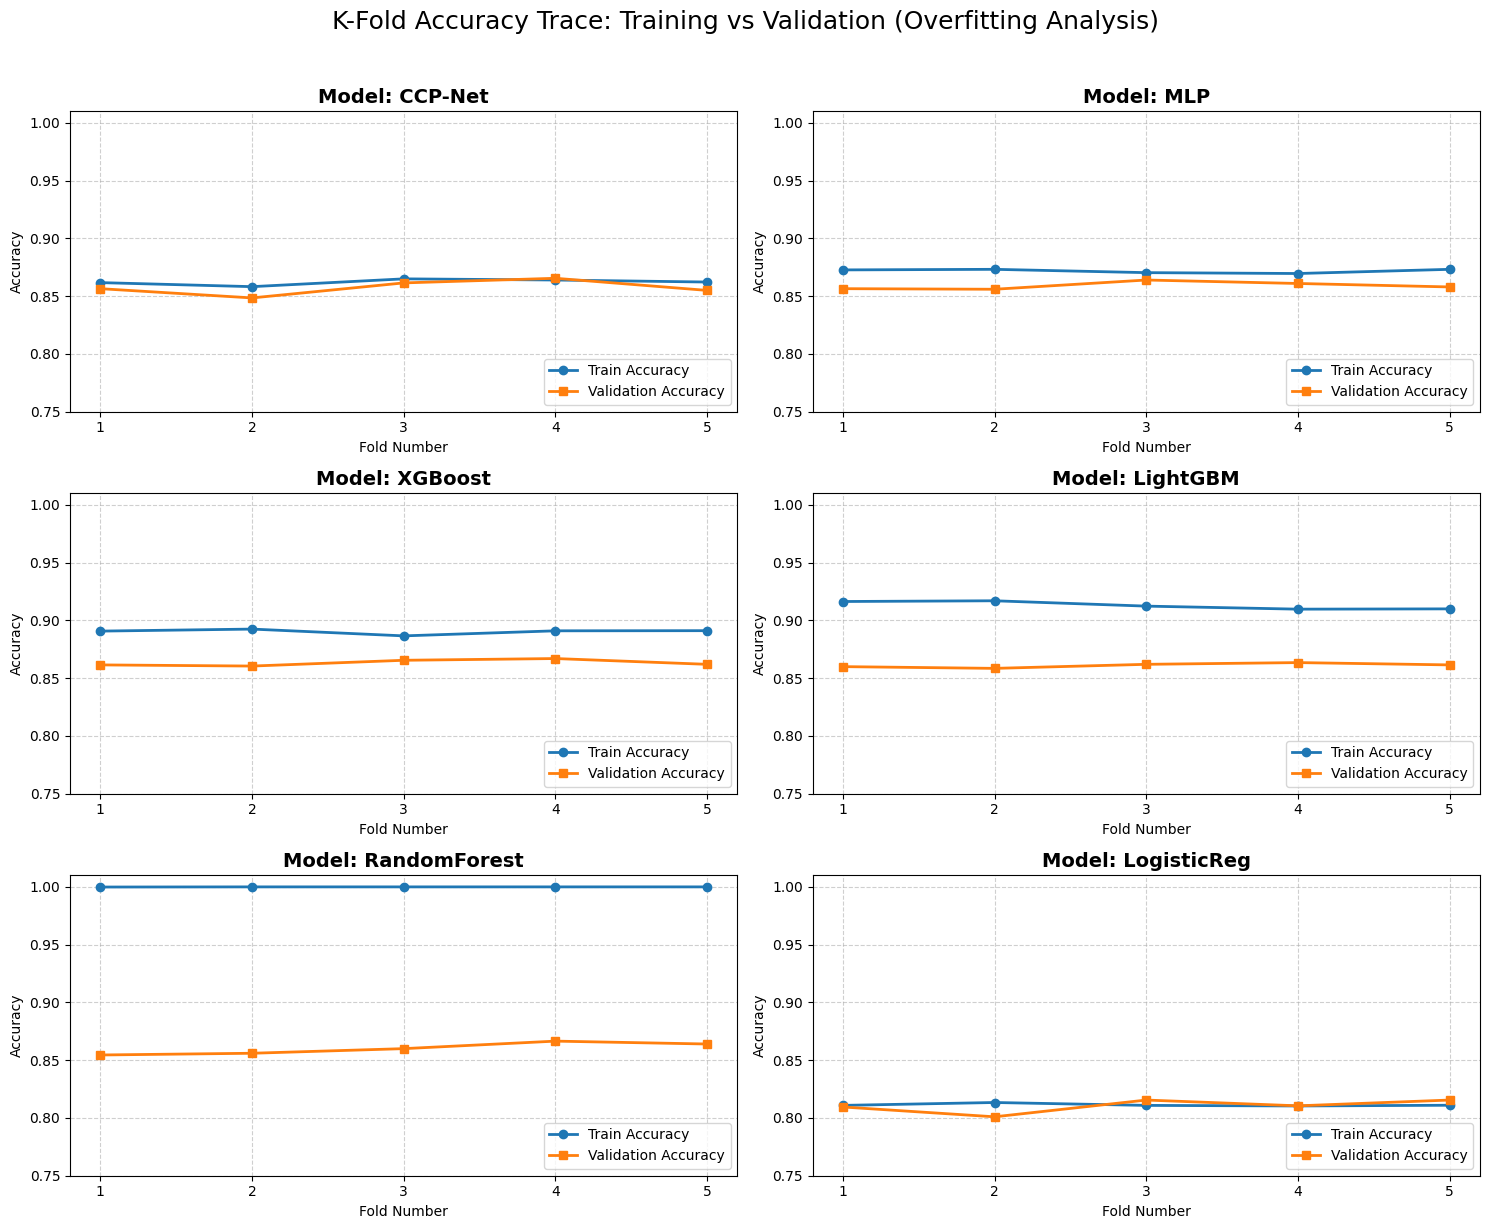

--- CCP-Net ---
Train Acc: 0.8622 (Folds: [0.8618, 0.8582, 0.865, 0.864, 0.8622])
Val Acc:   0.8574 (Folds: [0.8565, 0.8485, 0.8615, 0.8655, 0.855])
------------------------------
--- MLP ---
Train Acc: 0.8719 (Folds: [0.8728, 0.8732, 0.8704, 0.8696, 0.8732])
Val Acc:   0.8591 (Folds: [0.8565, 0.856, 0.864, 0.861, 0.858])
------------------------------
--- XGBoost ---
Train Acc: 0.8904 (Folds: [0.8908, 0.8925, 0.8866, 0.891, 0.8911])
Val Acc:   0.8633 (Folds: [0.8615, 0.8605, 0.8655, 0.867, 0.862])
------------------------------
--- LightGBM ---
Train Acc: 0.9131 (Folds: [0.9164, 0.917, 0.9124, 0.9097, 0.91])
Val Acc:   0.8611 (Folds: [0.86, 0.8585, 0.862, 0.8635, 0.8615])
------------------------------
--- RandomForest ---
Train Acc: 1.0000 (Folds: [0.9999, 1.0, 1.0, 1.0, 1.0])
Val Acc:   0.8602 (Folds: [0.8545, 0.856, 0.86, 0.8665, 0.864])
------------------------------
--- LogisticReg ---
Train Acc: 0.8113 (Folds: [0.8109, 0.8134, 0.8109, 0.8104, 0.811])
Val Acc:   0.8104 (Folds: [0

In [7]:
# ---------------------------------------------------------------
# Section 4: Final Results Comparison
# ---------------------------------------------------------------
end_time_total = time.time()
print("\n" + "="*50)
print("### Cross-Validation Results Summary ###")
print("="*50)

summary = {}
print("Model              | Average Accuracy | Std Dev")
print("-------------------|------------------|----------")
for model_name, acc_list in results.items():
    mean_acc = np.mean(acc_list)
    std_acc = np.std(acc_list)
    summary[model_name] = mean_acc
    print(f"{model_name:<18} | {mean_acc * 100:^16.2f}% | {std_acc * 100:.2f}%")

print(f"\nTotal Cross-Validation time: {end_time_total - start_time_total:.2f} seconds.")

# --- Find and Announce the Winner ---
winner = max(summary, key=summary.get)
print(f"\nConclusion: Based on average K-Fold accuracy, **{winner}** performs the best for this dataset.")

# Box Plot (Validation Accuracy)
df_val = pd.DataFrame(results)
df_val_melted = df_val.melt(var_name='Model', value_name='Accuracy')

# Bar Chart (Train vs Validation - Overfitting)
avg_train = {m: np.mean(v) for m, v in train_results.items()}
avg_val = {m: np.mean(v) for m, v in results.items()}

df_compare = pd.DataFrame({
    'Model': list(avg_train.keys()) + list(avg_val.keys()),
    'Accuracy': list(avg_train.values()) + list(avg_val.values()),
    'Dataset': ['Train'] * 6 + ['Validation'] * 6
})

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Box Plot
sns.boxplot(data=df_val_melted, x='Model', y='Accuracy', ax=ax[0], palette='Set2')
ax[0].set_title('K-Fold Validation Accuracy Distribution', fontsize=14)
ax[0].set_ylim(0.75, 0.95)
ax[0].grid(axis='y', linestyle='--', alpha=0.6)

# Grouped Bar Chart
sns.barplot(data=df_compare, x='Model', y='Accuracy', hue='Dataset', ax=ax[1], palette='viridis')
ax[1].set_title('Train vs. Validation Accuracy (Overfitting Check)', fontsize=14)
ax[1].set_ylim(0.75, 1.0)
ax[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

models = ["CCP-Net", "MLP", "XGBoost", "LightGBM", "RandomForest", "LogisticReg"]
folds = [1, 2, 3, 4, 5]

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for i, model_name in enumerate(models):

    train_acc = train_results[model_name]
    val_acc = results[model_name]

    axes[i].plot(folds, train_acc, marker='o', label='Train Accuracy', color='#1f77b4', linewidth=2)
    axes[i].plot(folds, val_acc, marker='s', label='Validation Accuracy', color='#ff7f0e', linewidth=2)

    axes[i].set_title(f'Model: {model_name}', fontsize=14, fontweight='bold')
    axes[i].set_xticks(folds)
    axes[i].set_xlabel('Fold Number')
    axes[i].set_ylabel('Accuracy')
    axes[i].set_ylim(0.75, 1.01)
    axes[i].legend(loc='lower right')
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('K-Fold Accuracy Trace: Training vs Validation (Overfitting Analysis)', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

for model_name in results.keys():
    print(f"--- {model_name} ---")
    print(f"Train Acc: {np.mean(train_results[model_name]):.4f} (Folds: {[round(x, 4) for x in train_results[model_name]]})")
    print(f"Val Acc:   {np.mean(results[model_name]):.4f} (Folds: {[round(x, 4) for x in results[model_name]]})")
    print("-" * 30)


### Section 5: Final Training & Detailed Evaluation for XGBoost ###
Preparing final Train/Test data (80/20 split)...
Final Train set size: 8000, Final Test set size: 2000

Training final XGBoost model...
Final XGBoost training complete!

--- Final Evaluation for XGBoost ---


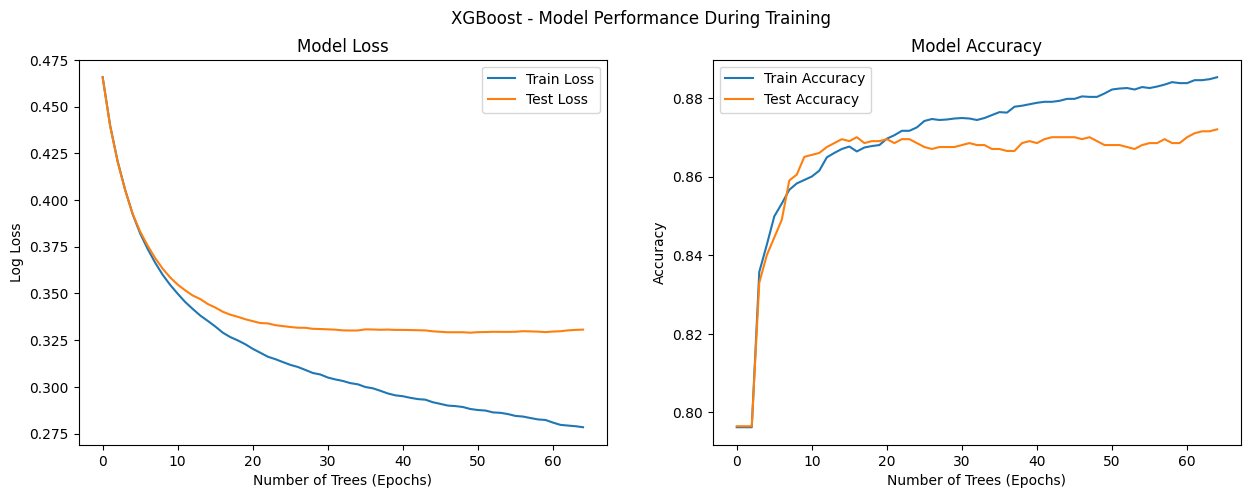


Final Model Accuracy (XGBoost): 87.20%

Classification Report (XGBoost):
               precision    recall  f1-score   support

Not Churn (0)       0.88      0.97      0.92      1593
    Churn (1)       0.80      0.49      0.61       407

     accuracy                           0.87      2000
    macro avg       0.84      0.73      0.77      2000
 weighted avg       0.87      0.87      0.86      2000


Confusion Matrix (XGBoost):


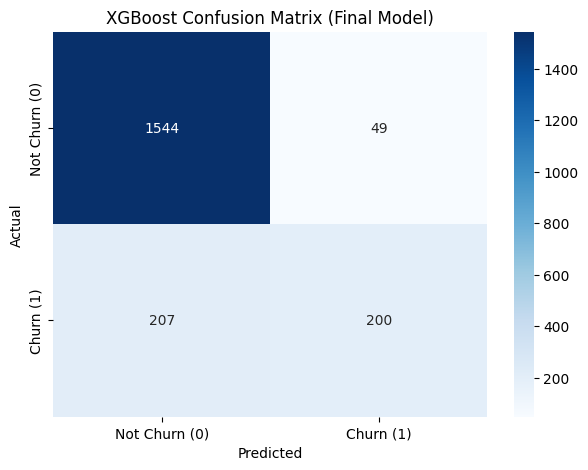


Feature Importance (XGBoost):


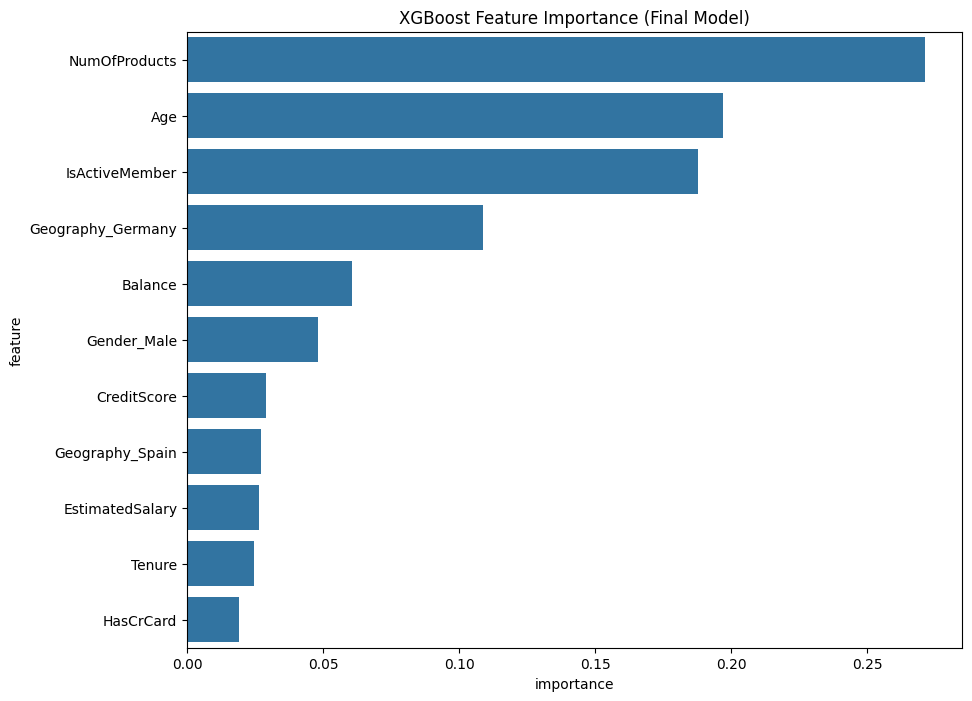


### Detailed evaluation for XGBoost complete! ###
--- XGBoost Feature Importance Ranking ---
             Feature  Importance Score
0      NumOfProducts          0.271300
1                Age          0.196855
2     IsActiveMember          0.187833
3  Geography_Germany          0.108944
4            Balance          0.060531
5        Gender_Male          0.048237
6        CreditScore          0.028993
7    Geography_Spain          0.027283
8    EstimatedSalary          0.026446
9             Tenure          0.024613


In [11]:
#################################################################
# Section 5: Final Training & Detailed Evaluation for XGBoost (The Winner)
#################################################################

print("\n" + "="*50)
print("### Section 5: Final Training & Detailed Evaluation for XGBoost ###")
print("="*50)


# --- 1. Train/Test(80/20 Split) ---
print("Preparing final Train/Test data (80/20 split)...")
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train_final_processed = preprocessor.fit_transform(X_train_final)
X_test_final_processed = preprocessor.transform(X_test_final)
X_train_final_scaled = X_train_final_processed.toarray() if hasattr(X_train_final_processed, "toarray") else X_train_final_processed
X_test_final_scaled = X_test_final_processed.toarray() if hasattr(X_test_final_processed, "toarray") else X_test_final_processed
y_test_final_np = y_test_final
print(f"Final Train set size: {len(X_train_final_scaled)}, Final Test set size: {len(X_test_final_scaled)}")

# --- 2. Train XGBoost  ---
print("\nTraining final XGBoost model...")
final_model_xgb = xgb.XGBClassifier(
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric=['logloss', 'error'],
    n_estimators=65,
    max_depth=5,
    learning_rate=0.13,
    random_state=RANDOM_STATE,
    gamma=0.2,
    early_stopping_rounds=0,
)

eval_set = [(X_train_final_scaled, y_train_final), (X_test_final_scaled, y_test_final_np)]
final_model_xgb.fit(X_train_final_scaled, y_train_final, eval_set=eval_set, verbose=False)

print("Final XGBoost training complete!")

print(f"\n--- Final Evaluation for XGBoost ---")

# --- Overfitting Curve (Loss & Accuracy) ---
results = final_model_xgb.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

# --- FIX: Figure 2 sub graph ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('XGBoost - Model Performance During Training')

# Plot Loss
ax1.plot(x_axis, results['validation_0']['logloss'], label='Train Loss')
ax1.plot(x_axis, results['validation_1']['logloss'], label='Test Loss')
ax1.set_title('Model Loss')
ax1.set_xlabel('Number of Trees (Epochs)'); ax1.set_ylabel('Log Loss'); ax1.legend()

# Plot Accuracy
train_acc = [1.0 - x for x in results['validation_0']['error']]
test_acc = [1.0 - x for x in results['validation_1']['error']]
ax2.plot(x_axis, train_acc, label='Train Accuracy')
ax2.plot(x_axis, test_acc, label='Test Accuracy')
ax2.set_title('Model Accuracy')
ax2.set_xlabel('Number of Trees (Epochs)'); ax2.set_ylabel('Accuracy'); ax2.legend()

plt.show()

# --- Accuracy & Classification Report ---
y_pred_final_xgb = final_model_xgb.predict(X_test_final_scaled)
final_accuracy_xgb = accuracy_score(y_test_final_np, y_pred_final_xgb)
print(f"\nFinal Model Accuracy (XGBoost): {final_accuracy_xgb * 100:.2f}%")

print("\nClassification Report (XGBoost):")
target_names = ['Not Churn (0)', 'Churn (1)']
print(classification_report(y_test_final_np, y_pred_final_xgb, target_names=target_names))

# --- Confusion Matrix ---
print("\nConfusion Matrix (XGBoost):")
cm_final_xgb = confusion_matrix(y_test_final_np, y_pred_final_xgb)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_final_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('XGBoost Confusion Matrix (Final Model)')
plt.show()

# --- Feature Importance ---
print("\nFeature Importance (XGBoost):")
feature_importances_xgb = pd.DataFrame({
    'feature': feature_names,
    'importance': final_model_xgb.feature_importances_
}).sort_values('importance', ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importances_xgb)
plt.title('XGBoost Feature Importance (Final Model)')
plt.show()

print("\n" + "="*50)
print("### Detailed evaluation for XGBoost complete! ###")
print("="*50)

feat_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance Score': final_model_xgb.feature_importances_
})

feat_importances = feat_importances.sort_values(by='Importance Score', ascending=False).reset_index(drop=True)

print("--- XGBoost Feature Importance Ranking ---")
print(feat_importances.head(10))


### Section 6: Part 2 - K-Means Clustering for 'Not Churn' Customers ###
Preprocessing all customer data...
Predicting churn for all customers using XGBoost...
Identified 8717 'Not Churn' customers for segmentation.

Finding optimal K using The Elbow Method...


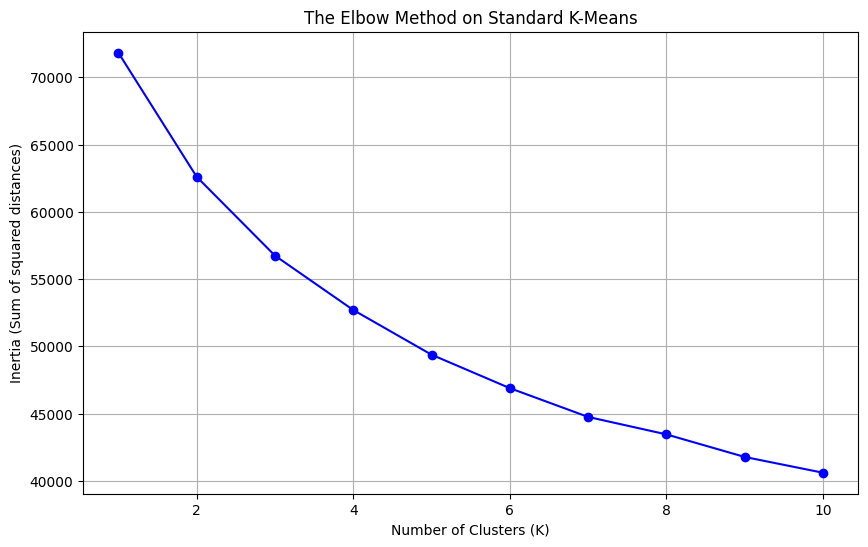

Please observe the 'Elbow' in the plot above to choose the optimal K.

Running final K-Means with K=4...

--- Cluster Analysis (Average Values) ---
         CreditScore        Age    Tenure        Balance  NumOfProducts  \
Cluster                                                                   
0         653.533935  37.524912  4.897999   75505.941353       1.525696   
1         653.929598  39.011973  4.904693  120041.126662       1.343391   
2         650.972176  37.406977  5.156977     762.820037       1.803571   
3         647.736842  35.291866  5.135766  121049.760778       1.360048   

         HasCrCard  IsActiveMember  EstimatedSalary  
Cluster                                              
0              0.0        0.556297    100437.859525  
1              1.0        1.000000     99404.322193  
2              1.0        0.547757     97863.564086  
3              1.0        0.000000    101422.893577  

--- Cluster Sizes ---
Cluster
0    2549
2    2408
1    2088
3    1672
Name: 

In [9]:
#################################################################
# Section 6: - Deeper Segmentation (K-Means Clustering)
#################################################################
from sklearn.cluster import KMeans

print("\n" + "="*50)
print("### Section 6: Part 2 - K-Means Clustering for 'Not Churn' Customers ###")
print("="*50)
print("Preprocessing all customer data...")
X_full_processed = preprocessor.transform(X)
X_full_scaled = X_full_processed.toarray() if hasattr(X_full_processed, "toarray") else X_full_processed

print("Predicting churn for all customers using XGBoost...")
all_churn_predictions = final_model_xgb.predict(X_full_scaled)
not_churn_mask = (all_churn_predictions == 0)
data_for_clustering = X_full_scaled[not_churn_mask]
not_churn_original_df = X[not_churn_mask].reset_index(drop=True)

print(f"Identified {len(data_for_clustering)} 'Not Churn' customers for segmentation.")

print("\nFinding optimal K using The Elbow Method...")
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    kmeans.fit(data_for_clustering)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of squared distances)')
plt.title('The Elbow Method on Standard K-Means')
plt.grid(True)
plt.show()

print("Please observe the 'Elbow' in the plot above to choose the optimal K.")

OPTIMAL_K = 4
print(f"\nRunning final K-Means with K={OPTIMAL_K}...")

kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=RANDOM_STATE)
kmeans.fit(data_for_clustering)
cluster_labels = kmeans.labels_

not_churn_original_df['Cluster'] = cluster_labels

print("\n--- Cluster Analysis (Average Values) ---")
cluster_analysis = not_churn_original_df.groupby('Cluster')[numerical_features].mean()
print(cluster_analysis)

print("\n--- Cluster Sizes ---")
print(not_churn_original_df['Cluster'].value_counts())

print("\n" + "="*50)
print("### Part 2: K-Means Clustering complete! ###")
print("="*50)


### Section 6: Part 2 - Autoencoder + K-Means ###
Preprocessing all customer data...
Predicting churn for all customers using XGBoost...
Identified 8717 'Not Churn' customers.
Autoencoder architecture defined (Input: 11, Bottleneck: 4)

Training Autoencoder on cpu...
Epoch 10/50, Reconstruction Loss: 0.334410
Epoch 20/50, Reconstruction Loss: 0.246375
Epoch 30/50, Reconstruction Loss: 0.197401
Epoch 40/50, Reconstruction Loss: 0.190009
Epoch 50/50, Reconstruction Loss: 0.187479
Autoencoder training complete.

Extracting learned embeddings...
Embeddings created. New data shape: (8717, 4)

Finding optimal K using The Elbow Method (on Embeddings)...


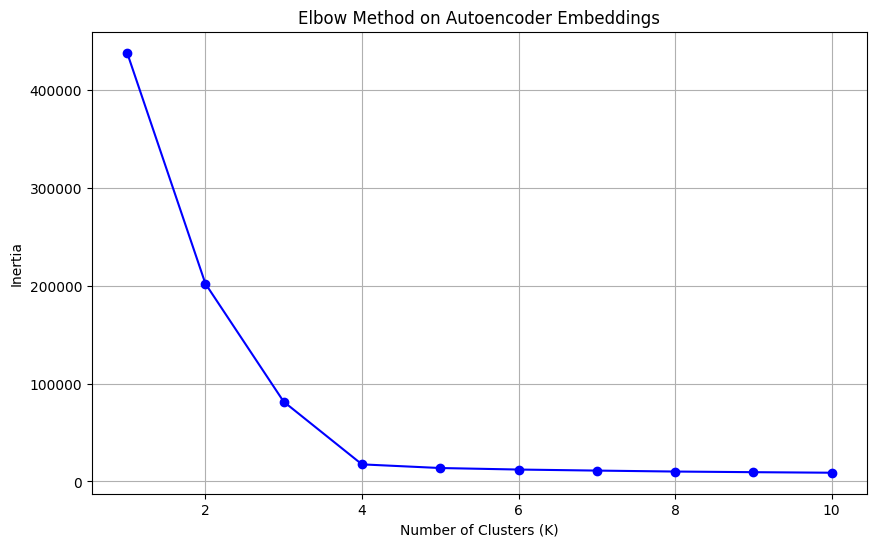


Running final K-Means (on Embeddings) with K=4...

--- Autoencoder + K-Means: Cluster Analysis (Average Values) ---
         CreditScore        Age    Tenure       Balance  NumOfProducts  \
Cluster                                                                  
0         653.328735  39.143528  5.002055  74014.954092       1.519225   
1         648.341543  35.197030  5.144513  73418.686907       1.537849   
2         654.313822  39.388575  4.782087  76720.426700       1.508463   
3         652.556145  35.188329  5.043324  73983.270955       1.547303   

         HasCrCard  IsActiveMember  EstimatedSalary  
Cluster                                              
0              1.0             1.0     98649.437452  
1              1.0             0.0    100214.462774  
2              0.0             1.0    100886.944154  
3              0.0             0.0     99874.816198  

--- Autoencoder + K-Means: Cluster Sizes ---
Cluster
0    3407
1    2761
2    1418
3    1131
Name: count, dtype: 

In [12]:
#################################################################
# Section 6: Part 2 (v2.0) - Autoencoder + K-Means Clustering
#################################################################

print("\n" + "="*50)
print("### Section 6: Part 2 - Autoencoder + K-Means ###")
print("="*50)

print("Preprocessing all customer data...")
X_full_processed = preprocessor.transform(X)
X_full_scaled = X_full_processed.toarray() if hasattr(X_full_processed, "toarray") else X_full_processed

print("Predicting churn for all customers using XGBoost...")
all_churn_predictions = final_model_xgb.predict(X_full_scaled)

# Only "Not Churn" (Predicted == 0)
not_churn_mask = (all_churn_predictions == 0)
data_for_ae_training = X_full_scaled[not_churn_mask] #
not_churn_original_df = X[not_churn_mask].reset_index(drop=True)

print(f"Identified {len(data_for_ae_training)} 'Not Churn' customers.")

# ---------------------------------------------------------------
# --- 2.  Autoencoder ---
# ---------------------------------------------------------------

INPUT_DIM = data_for_ae_training.shape[1]
EMBEDDING_DIM = 4

class Autoencoder(nn.Module):
    def __init__(self, input_dim, embedding_dim):
        super(Autoencoder, self).__init__()

        # --- Encoder ---
        # 11 -> 8 -> 4
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Linear(8, embedding_dim)
        )

        # --- Decoder ---
        # 4 -> 8 -> 11
        self.decoder = nn.Sequential(
            nn.Linear(embedding_dim, 8),
            nn.ReLU(),
            nn.Linear(8, input_dim)
        )

    def forward(self, x):

        encoded = self.encoder(x)

        decoded = self.decoder(encoded)
        return decoded

print(f"Autoencoder architecture defined (Input: {INPUT_DIM}, Bottleneck: {EMBEDDING_DIM})")

# ---------------------------------------------------------------
# --- 3. Train Autoencoder ---
# ---------------------------------------------------------------

ae_dataset = TensorDataset(torch.tensor(data_for_ae_training.astype(np.float32)))
ae_loader = DataLoader(ae_dataset, batch_size=32, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder = Autoencoder(INPUT_DIM, EMBEDDING_DIM).to(device)
loss_fn_ae = nn.MSELoss()
optimizer_ae = torch.optim.Adam(autoencoder.parameters(), lr=0.001)
NUM_EPOCHS_AE = 50

print(f"\nTraining Autoencoder on {device}...")
for epoch in range(NUM_EPOCHS_AE):
    total_loss = 0
    for data in ae_loader:
        X_batch = data[0].to(device)
        X_reconstructed = autoencoder(X_batch)
        loss = loss_fn_ae(X_reconstructed, X_batch)

        optimizer_ae.zero_grad()
        loss.backward()
        optimizer_ae.step()
        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS_AE}, Reconstruction Loss: {total_loss / len(ae_loader):.6f}")

print("Autoencoder training complete.")

# ---------------------------------------------------------------
# --- 4. Embeddings ---
# ---------------------------------------------------------------
print("\nExtracting learned embeddings...")
autoencoder.eval() # สั่งให้โมเดลอยู่ในโหมดประเมินผล
with torch.no_grad():
    data_tensor = torch.tensor(data_for_ae_training.astype(np.float32)).to(device)
    # --- ใช้เฉพาะส่วน "Encoder" เพื่อ "ย่อ" ข้อมูล ---
    embeddings = autoencoder.encoder(data_tensor).cpu().numpy()

print(f"Embeddings created. New data shape: {embeddings.shape}") # (จำนวนลูกค้า, 4)

# ---------------------------------------------------------------
# --- 5. K-Means  ---
# ---------------------------------------------------------------
print("\nFinding optimal K using The Elbow Method (on Embeddings)...")
inertia_ae = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    kmeans.fit(embeddings)
    inertia_ae.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia_ae, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method on Autoencoder Embeddings')
plt.grid(True)
plt.show()

OPTIMAL_K = 4
print(f"\nRunning final K-Means (on Embeddings) with K={OPTIMAL_K}...")

kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=RANDOM_STATE)
kmeans.fit(embeddings)
cluster_labels = kmeans.labels_

not_churn_original_df['Cluster'] = cluster_labels

print("\n--- Autoencoder + K-Means: Cluster Analysis (Average Values) ---")
cluster_analysis = not_churn_original_df.groupby('Cluster')[numerical_features].mean()
print(cluster_analysis)

print("\n--- Autoencoder + K-Means: Cluster Sizes ---")
print(not_churn_original_df['Cluster'].value_counts())

print("\n" + "="*50)
print("### Part 2 (v2.0): Autoencoder + K-Means complete! ###")
print("="*50)


### Section 6 (v2.1): Deep Autoencoder + K-Means ###
Re-using 'Not Churn' data from previous run...
Working with 8717 'Not Churn' customers.
Deep Autoencoder architecture defined (Input: 11, Bottleneck: 4)

Training Deep Autoencoder on cpu...
Epoch 10/50, Reconstruction Loss: 0.295977
Epoch 20/50, Reconstruction Loss: 0.228001
Epoch 30/50, Reconstruction Loss: 0.219351
Epoch 40/50, Reconstruction Loss: 0.217297
Epoch 50/50, Reconstruction Loss: 0.216211
Deep Autoencoder training complete.

Extracting learned embeddings from Deep AE...
Embeddings created. New data shape: (8717, 4)

Finding optimal K using The Elbow Method (on Deep Embeddings)...


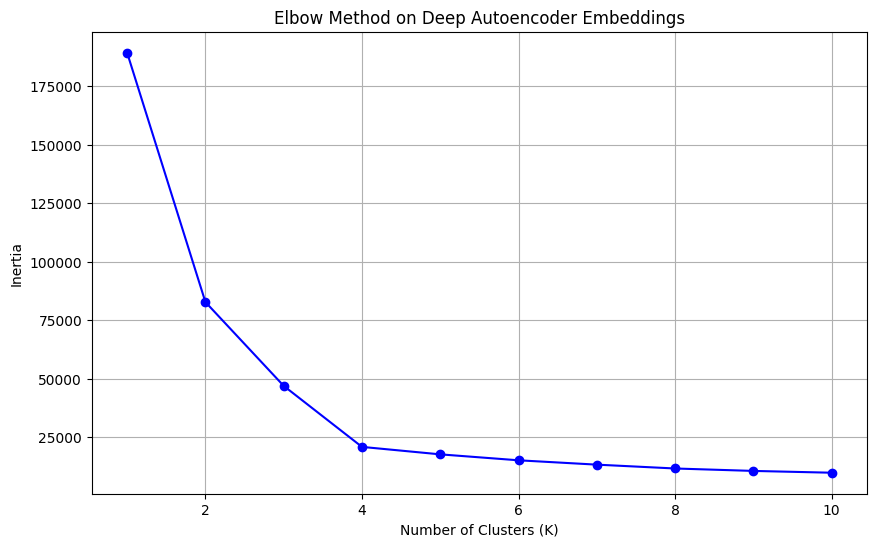


Running final K-Means (on Deep Embeddings) with K=4...

--- Deep Autoencoder + K-Means: Cluster Analysis (Average Values) ---
         CreditScore        Age    Tenure        Balance  NumOfProducts  \
Cluster                                                                   
0         654.551121  39.165237  4.839050  119044.069941       1.351253   
1         649.347625  35.188654  5.128628      11.894123       1.817282   
2         649.705808  35.198232  5.106481  120524.428666       1.364057   
3         652.040714  39.300613  5.103737       9.421969       1.794757   

         HasCrCard  IsActiveMember  EstimatedSalary  
Cluster                                              
0         0.697559             1.0    100043.352761  
1         0.714380             0.0     98795.429485  
2         0.706229             0.0    100958.197702  
3         0.720580             1.0     98061.837501  

--- Deep Autoencoder + K-Means: Cluster Sizes ---
Cluster
0    3032
2    2376
3    1793
1    1516

In [13]:
#################################################################
# Section 6 (v2.1): Deep Autoencoder + K-Means Clustering
#################################################################

print("\n" + "="*50)
print("### Section 6 (v2.1): Deep Autoencoder + K-Means ###")
print("="*50)

# --- 1. "Not Churn"  ---
print("Re-using 'Not Churn' data from previous run...")
print(f"Working with {len(data_for_ae_training)} 'Not Churn' customers.")

# ---------------------------------------------------------------
# --- 2. "Deep" Autoencoder ---
# ---------------------------------------------------------------

INPUT_DIM = data_for_ae_training.shape[1]
EMBEDDING_DIM = 4

class DeepAutoencoder(nn.Module):
    def __init__(self, input_dim, embedding_dim):
        super(DeepAutoencoder, self).__init__()

        # --- Encoder ---
        # 11 -> 16 -> 8 -> 4
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, embedding_dim)
        )

        # --- Decoder ---
        # 4 -> 8 -> 16 -> 11
        self.decoder = nn.Sequential(
            nn.Linear(embedding_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

print(f"Deep Autoencoder architecture defined (Input: {INPUT_DIM}, Bottleneck: {EMBEDDING_DIM})")

# ---------------------------------------------------------------
# --- 3. Train Deep Autoencoder ---
# ---------------------------------------------------------------

ae_dataset = TensorDataset(torch.tensor(data_for_ae_training.astype(np.float32)))
ae_loader = DataLoader(ae_dataset, batch_size=32, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder_deep = DeepAutoencoder(INPUT_DIM, EMBEDDING_DIM).to(device)
loss_fn_ae = nn.MSELoss()
optimizer_ae = torch.optim.Adam(autoencoder_deep.parameters(), lr=0.001)
NUM_EPOCHS_AE = 50

print(f"\nTraining Deep Autoencoder on {device}...")
for epoch in range(NUM_EPOCHS_AE):
    total_loss = 0
    for data in ae_loader:
        X_batch = data[0].to(device)
        X_reconstructed = autoencoder_deep(X_batch)
        loss = loss_fn_ae(X_reconstructed, X_batch)
        optimizer_ae.zero_grad(); loss.backward(); optimizer_ae.step()
        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS_AE}, Reconstruction Loss: {total_loss / len(ae_loader):.6f}")

print("Deep Autoencoder training complete.")

# ---------------------------------------------------------------
# --- 4. Embeddings ---
# ---------------------------------------------------------------
print("\nExtracting learned embeddings from Deep AE...")
autoencoder_deep.eval()
with torch.no_grad():
    data_tensor = torch.tensor(data_for_ae_training.astype(np.float32)).to(device)
    embeddings = autoencoder_deep.encoder(data_tensor).cpu().numpy() # ใช้ encoder ของโมเดลใหม่

print(f"Embeddings created. New data shape: {embeddings.shape}")

# ---------------------------------------------------------------
# --- 5. K-Means  ---
# ---------------------------------------------------------------

print("\nFinding optimal K using The Elbow Method (on Deep Embeddings)...")
inertia_ae_deep = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    kmeans.fit(embeddings)
    inertia_ae_deep.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia_ae_deep, 'bo-')
plt.xlabel('Number of Clusters (K)'); plt.ylabel('Inertia')
plt.title('Elbow Method on Deep Autoencoder Embeddings'); plt.grid(True); plt.show()

OPTIMAL_K = 4
print(f"\nRunning final K-Means (on Deep Embeddings) with K={OPTIMAL_K}...")

kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=RANDOM_STATE)
kmeans.fit(embeddings)
cluster_labels = kmeans.labels_
not_churn_original_df['Cluster'] = cluster_labels

print("\n--- Deep Autoencoder + K-Means: Cluster Analysis (Average Values) ---")
cluster_analysis = not_churn_original_df.groupby('Cluster')[numerical_features].mean()
print(cluster_analysis)

print("\n--- Deep Autoencoder + K-Means: Cluster Sizes ---")
print(not_churn_original_df['Cluster'].value_counts())

print("\n" + "="*50)
print("### Part 2 (v2.1): Deep Autoencoder + K-Means complete! ###")
print("="*50)